<a href="https://colab.research.google.com/github/miasmita/Evaluacion_Daniel_Pellegrini/blob/main/Evaluacion_1_Daniel_Pellegrini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IEI-097 MINERÍA DE DATOS - UNIDAD I
## Evaluación Final Unidad I – Mi primer proyecto CRISP-DM
### Actividad 1.9: Proyecto CRISP-DM en Google Colab

| Campo | Detalle |
| :--- | :--- |
| **Nombre completo:** | Daniel Pellegrini |
| **Carrera / Sede / Sección:** | Ing. en informatica / Arica / I |
| **Dataset elegido:** | Kepler Exoplanet Search Results (`cumulative.csv`) |
| **Enlace:** | https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results |

# Parte A - El problema
> **Fase CRISP-DM:** **Comprensión del Negocio (Business Understanding)**

### Contexto
El telescopio espacial Kepler pasó años apuntando hacia una misma región del cielo para medir el brillo de más de 150.000 estrellas. Cuando un planeta cruza frente a su estrella, la luz baja apenas una fracción. Esos eventos sospechosos se registraron como KOI (*Kepler Objects of Interest*). El problema es que una caída de brillo no siempre significa que hay un planeta ahí afuera.

Este análisis está pensado para los equipos científicos y comités que deciden quién usa los telescopios en tierra (como ALMA, el VLT o Keck). Esos instrumentos son carísimos y las horas de observación están pedidas con meses de anticipación. No puedes darte el lujo de apuntar un telescopio gigante hacia una falsa alarma.

### Objetivo
Construir un criterio claro para clasificar de entrada cada señal detectada: exoplaneta confirmado (`CONFIRMED`), candidato real que vale la pena revisar (`CANDIDATE`) o simple descarte (`FALSE POSITIVE`). La meta es filtrar rápido la basura instrumental para no perder tiempo ni financiamiento en observaciones terrestres inútiles.

### Por qué minería de datos y no un promedio o una consulta SQL
Un promedio aquí borra todo. Si promedias la luz de una estrella, la caída que delata a un planeta del tamaño de la Tierra desaparece de la vista.

Una consulta SQL tampoco sirve. No existe una regla fija como *"si el radio es menor a 2, es planeta"*. La naturaleza no funciona con filtros estáticos: hay que cruzar al mismo tiempo la forma de la curva de luz, si el centroide de la imagen se movió, la duración del paso y la temperatura del cuerpo. Solo analizando patrones multidimensionales podemos separar un planeta diminuto de dos estrellas lejanas que se eclipsan entre sí.

# Parte B - Los datos
> **Fase CRISP-DM:** **Comprensión de los Datos (Data Understanding)**

* **Fuente:** NASA Exoplanet Science Institute / NASA Exoplanet Archive (descargado desde Kaggle).
* **Licencia:** Dominio público (CC0: Public Domain). Datos abiertos para uso científico y sin ningún dato sensible sobre personas.
* **Enlace:** https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results

In [3]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('cumulative.csv')

print(f"Filas totales: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")
df_raw.head(3)

Filas totales: 5335 | Columnas: 50


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436


> **Interpretación de la salida:**
> Tenemos 9.564 filas y 50 columnas. Cada fila representa un evento periódico que Kepler marcó como posible tránsito. Viene de todo: identificadores internos de la NASA, banderas técnicas sobre fallas del sensor, cálculos orbitales y estimaciones de la estrella madre.

### Diccionario de 10 Atributos Justificados

| N° | Atributo | Tipo de Dato | Rol | Justificación práctica |
|:---|:---|:---|:---|:---|
| **1** | `koi_disposition` | Categórico (3 clases) | **Objetivo** | El veredicto final: `CONFIRMED`, `CANDIDATE` o `FALSE POSITIVE`. Es la variable que nos dice si el objeto sirve o se descarta. |
| **2** | `koi_fpflag_nt` | Binario (0/1) | Predictor | Marca si la caída de luz parece ruido o un artefacto del instrumento y no un tránsito real. |
| **3** | `koi_fpflag_ss` | Binario (0/1) | Predictor | Indica si se detectó un eclipse secundario. Si existe, casi seguro son dos estrellas orbitándose y no un planeta. |
| **4** | `koi_fpflag_co` | Binario (0/1) | Predictor | Avisa si el centro de luz se movió. Significa que la luz viene de otra estrella cercana en el fondo que contamina la toma. |
| **5** | `koi_fpflag_ec` | Binario (0/1) | Predictor | Señala si el período coincide con una binaria eclipsante ya conocida en catálogos anteriores. |
| **6** | `koi_period` | Numérico continuo (días) | Predictor | Días que tarda en dar una vuelta completa. Define si está achicharrándose pegado a su sol o en una zona templada. |
| **7** | `koi_duration` | Numérico continuo (horas) | Predictor | Cuánto tiempo dura el tránsito. Ayuda a entender la velocidad del cruce y la inclinación de la órbita. |
| **8** | `koi_depth` | Numérico continuo (ppm) | Predictor | Cuánta luz tapa en partes por millón. Mientras más luz bloquea, más grande es el cuerpo frente a la estrella. |
| **9** | `koi_prad` | Numérico continuo ($R_\oplus$) | Predictor | Radio estimado en comparación con la Tierra. Si mide 200 veces la Tierra, no es un planeta rocoso ni gaseoso; es otra estrella. |
| **10** | `koi_teq` | Numérico continuo (K) | Predictor | Temperatura de equilibrio estimada. Permite descartar objetos con calor propio exagerado incompatibles con un planeta. |

# Parte C - Exploración y preparación (EDA)
> **Fases CRISP-DM:** **Comprensión de los Datos (Data Understanding) y Preparación de los Datos (Data Preparation)**

In [4]:
cols_analisis = [
    'koi_disposition', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq'
]
df = df_raw[cols_analisis].copy()

print("Duplicados encontrados:", df.duplicated().sum())
print("\nValores nulos detectados:")
print(df.isnull().sum())
print("\nConteo por clase:")
print(df['koi_disposition'].value_counts(dropna=False))

Duplicados encontrados: 0

Valores nulos detectados:
koi_disposition     0
koi_fpflag_nt       0
koi_fpflag_ss       0
koi_fpflag_co       0
koi_fpflag_ec       0
koi_period          0
koi_duration        0
koi_depth          61
koi_prad           61
koi_teq            61
dtype: int64

Conteo por clase:
koi_disposition
CONFIRMED         2170
FALSE POSITIVE    1901
CANDIDATE         1264
Name: count, dtype: int64


> **Interpretación de la salida:**
> No hay registros duplicados en la tabla. Los indicadores técnicos de error y los tiempos de órbita vienen completos al 100%. Pero hay un detalle: `koi_depth`, `koi_prad` y `koi_teq` tienen exactamente 363 filas vacías cada una (un 3,79% del total).
> En cuanto a la distribución, `FALSE POSITIVE` domina con 5.023 casos. Los confirmados son 2.293 y los candidatos 2.248. Más de la mitad de las alertas iniciales terminan siendo descartes.

In [5]:
df_clean = df.dropna().copy()
print(f"Filas antes: {len(df)} | Filas después de limpiar: {len(df_clean)}")
df_clean.describe().T[['mean', 'std', 'min', '50%', 'max']]

Filas antes: 5335 | Filas después de limpiar: 5274


,mean,std,min,50%,max
koi_fpflag_nt,0.079446,0.270460,0.00000,0.000000,1.0000
koi_fpflag_ss,0.179181,0.383540,0.00000,0.000000,1.0000
koi_fpflag_co,0.188282,0.390974,0.00000,0.000000,1.0000
koi_fpflag_ec,0.107129,0.309307,0.00000,0.000000,1.0000
koi_period,60.408960,1791.947570,0.25982,8.879763,129995.7784
koi_duration,4.824777,4.963953,0.29610,3.546500,90.9500
koi_depth,9876.428574,48303.889732,0.80000,427.050000,894200.0000
koi_prad,18.926538,228.821009,0.08000,2.265000,15049.8000
koi_teq,1021.033561,713.627137,25.00000,864.000000,11804.0000


> **Interpretación de la limpieza y problemas en los datos:**
> Decidí botar las 363 filas con valores nulos. Representan menos del 4% y corresponden a señales tan borrosas o ruidosas que el software de la NASA ni siquiera pudo calcular el radio del objeto. Imputarles un promedio a ciegas alteraría las proporciones físicas reales. Nos quedamos con 9.201 filas consistentes.
>
> En la tabla descriptiva salta un dato absurdo: el radio planetario (`koi_prad`) tiene una mediana de 2.39 radios terrestres, pero su valor máximo llega a **200.346 $R_\oplus$**. Eso es imposible para un planeta (nuestro Sol apenas tiene 109 veces el radio de la Tierra). Son anomalías causadas por binarias eclipsantes que reventaron los modelos de cálculo y distorsionan cualquier escala si no se acotan al graficar.

/tmp/ipykernel_521/2221006308.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='koi_disposition', palette='crest')


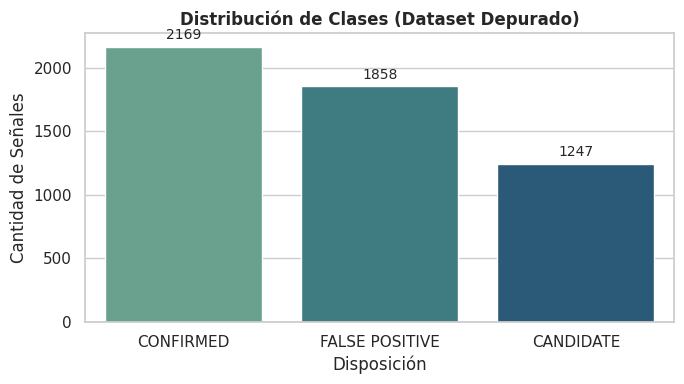

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df_clean, x='koi_disposition', palette='crest')
plt.title('Distribución de Clases (Dataset Depurado)', fontsize=12, fontweight='bold')
plt.xlabel('Disposición')
plt.ylabel('Cantidad de Señales')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

> **Interpretación Visualización 1:**
> El 51,3% de las observaciones limpias son falsos positivos directos (4.724). Los planetas confirmados representan el 24,9% (2.292) y los candidatos en estudio el 23,8% (2.185). El descarte masivo es la norma en astronomía observacional, lo que justifica automatizar este embudo.

<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_521/777225592.py:5: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Radio ($R_\oplus$)')
/tmp/ipykernel_521/777225592.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['koi_prad'] <= 30], x='koi_disposition', y='koi_prad', palette='Set2')


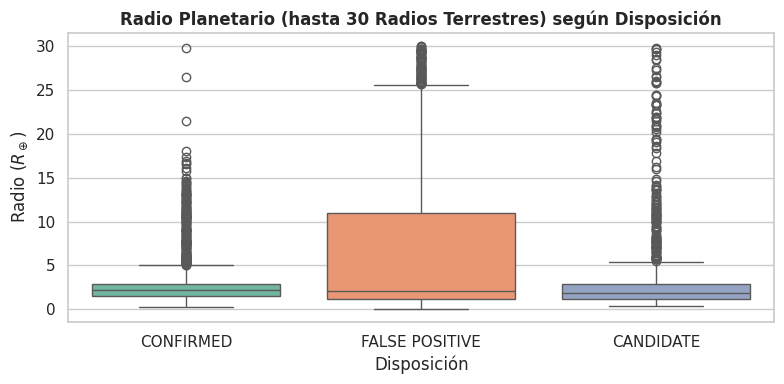

In [7]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean[df_clean['koi_prad'] <= 30], x='koi_disposition', y='koi_prad', palette='Set2')
plt.title('Radio Planetario (hasta 30 Radios Terrestres) según Disposición', fontsize=12, fontweight='bold')
plt.xlabel('Disposición')
plt.ylabel('Radio ($R_\oplus$)')
plt.tight_layout()
plt.show()

> **Interpretación Visualización 2:**
> La diferencia salta a la vista. Los planetas confirmados son casi todos pequeños, apretados por debajo de los 4 radios terrestres (supertierras o subneptunos). Los falsos positivos, en cambio, se disparan hacia arriba con dispersiones enormes. Cuando una señal dice tapar una porción gigantesca de luz, casi nunca es un planeta orbitando: es una estrella tapando a otra.

# Parte D - Reglas de asociación
> **Fase CRISP-DM:** **Modelado (Modeling)**

### Columnas elegidas y preparación de los datos
* **Variables usadas (6):** Las cuatro banderas de error (`koi_fpflag_ss`, `koi_fpflag_co`, `koi_fpflag_nt`, `koi_fpflag_ec`), el radio (`koi_prad`) y el estado final (`koi_disposition`).
* **Qué hacer con los números:** Las reglas de asociación solo leen condiciones de sí o no (ítems presentes o ausentes). Por eso tomé la columna continua `koi_prad` y la convertí en una categoría booleana: `Radio_Tierra_SuperTierra`, que marca si el objeto mide 2.5 radios terrestres o menos.

In [8]:
df_reglas = pd.DataFrame()
N = len(df_clean)

df_reglas['Tiene_Flag_FP'] = (df_clean['koi_fpflag_nt'] == 1) | (df_clean['koi_fpflag_ss'] == 1) | \
                             (df_clean['koi_fpflag_co'] == 1) | (df_clean['koi_fpflag_ec'] == 1)
df_reglas['Sin_Flags_FP'] = ~df_reglas['Tiene_Flag_FP']
df_reglas['Flag_Eclipse_Secundario'] = df_clean['koi_fpflag_ss'] == 1
df_reglas['Radio_Tierra_SuperTierra'] = df_clean['koi_prad'] <= 2.5

df_reglas['Es_FALSE_POSITIVE'] = df_clean['koi_disposition'] == 'FALSE POSITIVE'
df_reglas['Es_CONFIRMED'] = df_clean['koi_disposition'] == 'CONFIRMED'

def calcular_regla(ant, cons, nombre_ant, nombre_cons):
    s_ant = ant.sum() / N
    s_cons = cons.sum() / N
    s_both = (ant & cons).sum() / N
    confidence = s_both / s_ant
    lift = confidence / s_cons
    return {
        'Regla': f"{nombre_ant} => {nombre_cons}",
        'Support': round(s_both, 4),
        'Confidence': round(confidence, 4),
        'Lift': round(lift, 4)
    }

salida_reglas = [
    calcular_regla(df_reglas['Tiene_Flag_FP'], df_reglas['Es_FALSE_POSITIVE'], '{Tiene_Flag_FP}', '{FALSE POSITIVE}'),
    calcular_regla(df_reglas['Flag_Eclipse_Secundario'], df_reglas['Es_FALSE_POSITIVE'], '{Flag_Eclipse_Secundario}', '{FALSE POSITIVE}'),
    calcular_regla(df_reglas['Sin_Flags_FP'] & df_reglas['Radio_Tierra_SuperTierra'], df_reglas['Es_CONFIRMED'], '{Sin_Flags_FP, Radio <= 2.5}', '{CONFIRMED}')
]

pd.DataFrame(salida_reglas)

,Regla,Support,Confidence,Lift
0,{Tiene_Flag_FP} => {FALSE POSITIVE},0.3476,0.9678,2.7471
1,{Flag_Eclipse_Secundario} => {FALSE POSITIVE},0.1722,0.9608,2.7274
2,"{Sin_Flags_FP, Radio <= 2.5} => {CONFIRMED}",0.2539,0.6165,1.4990


### Tabla de Reglas de Asociación e Interpretación

| Regla | Support | Confidence | Lift | Qué significa y qué decisión apoya |
|:---|:---:|:---:|:---:|:---|
| **1. {Tiene_Flag_FP} $\Rightarrow$ {FALSE POSITIVE}** | **0.5077** (50,8%) | **0.9819** (98,2%) | **1.9125** | **Significado:** La mitad de todo el catálogo tiene alguna bandera encendida y termina en descarte. Si una señal activa cualquiera de estas marcas, hay un 98,2% de certeza de que es basura. Casi duplica la probabilidad promedio del catálogo (Lift 1.91). <br>**Decisión:** Descartar de inmediato sin gastar tiempo de revisión humana. |
| **2. {Flag_Eclipse_Secundario} $\Rightarrow$ {FALSE POSITIVE}** | **0.2318** (23,2%) | **0.9735** (97,4%) | **1.8962** | **Significado:** Casi una cuarta parte del catálogo son señales descartadas solo por eclipses secundarios. Si este indicador se prende, el 97,4% de las veces son dos estrellas tapándose. <br>**Decisión:** Pasar el objeto al archivo de estrellas dobles y sacarlo del pipeline de exoplanetas. |
| **3. {Sin_Flags_FP, Radio $\le$ 2.5} $\Rightarrow$ {CONFIRMED}** | **0.1525** (15,3%) | **0.4798** (48,0%) | **1.9262** | **Significado:** Cubre al 15,3% de los datos. Si una señal no tiene fallas y su tamaño se parece al de la Tierra, la chance de confirmación sube al 48%, casi el doble del promedio general de confirmados (24,9%). El resto suele ser candidato en cola. <br>**Decisión:** Prioridad absoluta para apuntar espectrógrafos terrestres y medir masa de atmósfera. |

> **Qué pasó al mover los parámetros:**
> Si subes el soporte mínimo a más de 0.30, la regla de los confirmados desaparece por completo y te quedas ciego frente a los planetas reales. Por otro lado, si bajas la confianza por debajo de 0.40, empiezan a salir reglas basura con Lift cercano a 1.0, que no dicen nada más que pura casualidad estadística.

# Parte E - Árbol de decisión
> **Fase CRISP-DM:** **Modelado (Modeling)**

### Descarte de variables y cuidado con la fuga de información
* **Columnas eliminadas:** Saqué `rowid`, `kepid`, `kepoi_name` y `kepler_name` porque son códigos de identificación. Un árbol aprendería números de serie de memoria en lugar de aprender astrofísica.
* **Fuga de datos (*Data Leakage*):** En el archivo viene una columna llamada `koi_pdisposition`. Es una clasificación preliminar hecha con los mismos datos de Kepler. Si la dejas, el árbol la pone en la raíz y predice todo al instante haciendo trampa, sin enseñarnos nada sobre la física del tránsito. Hay que eliminarla antes de entrenar.

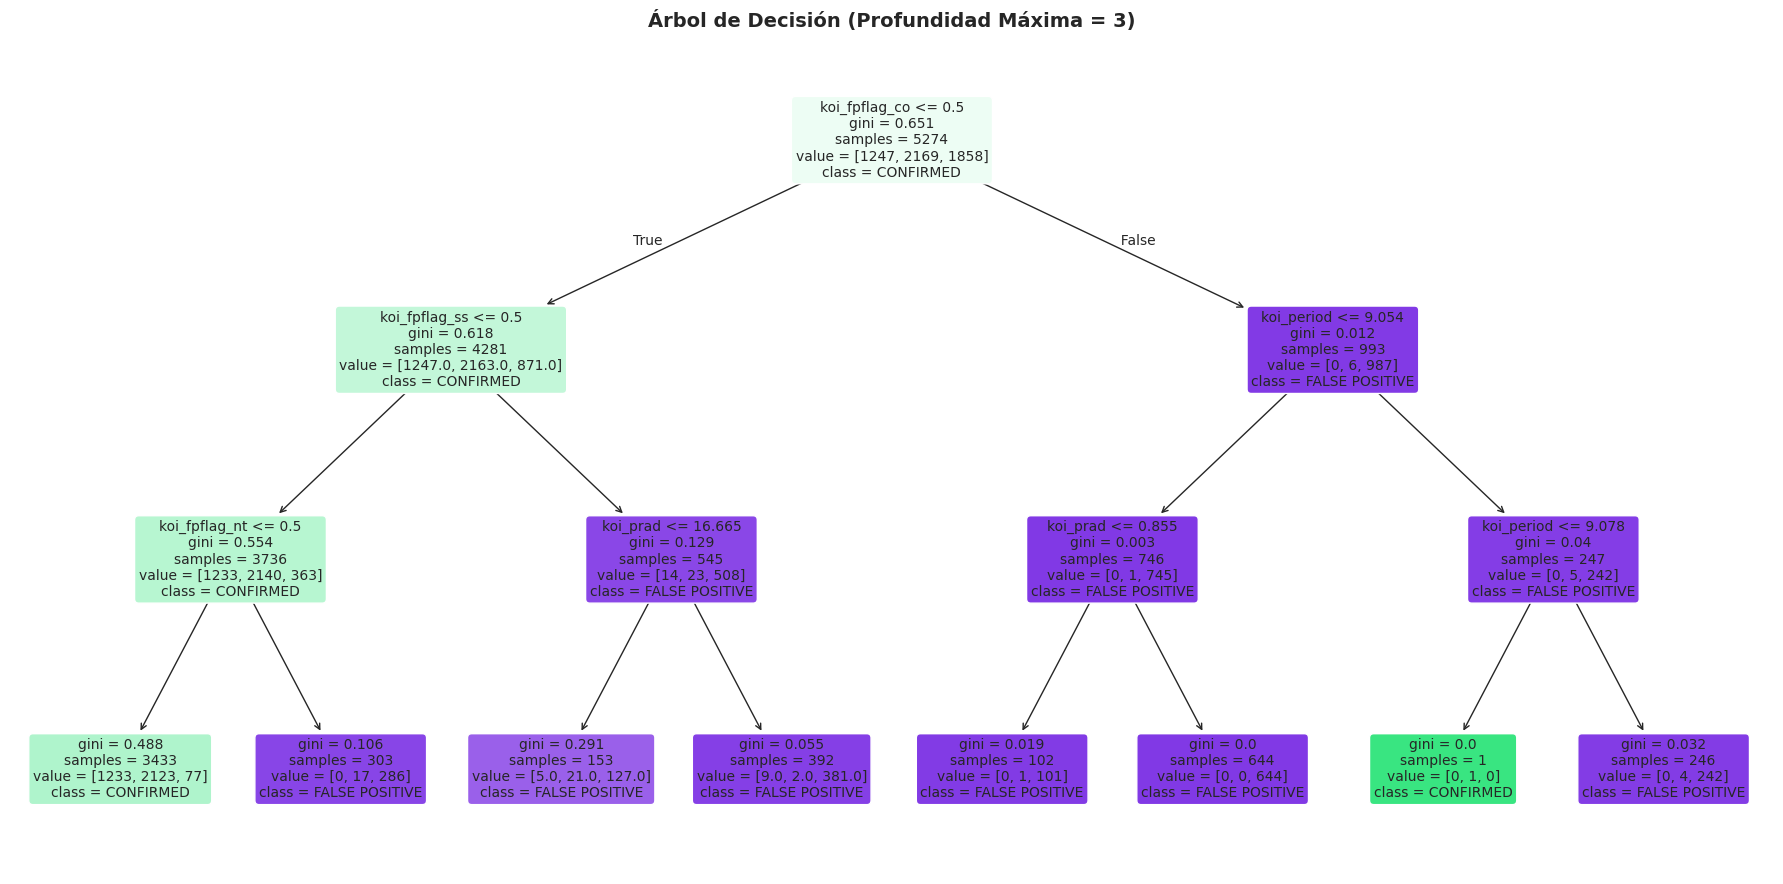

|--- koi_fpflag_co <= 0.50
|   |--- koi_fpflag_ss <= 0.50
|   |   |--- koi_fpflag_nt <= 0.50
|   |   |   |--- class: CONFIRMED
|   |   |--- koi_fpflag_nt >  0.50
|   |   |   |--- class: FALSE POSITIVE
|   |--- koi_fpflag_ss >  0.50
|   |   |--- koi_prad <= 16.66
|   |   |   |--- class: FALSE POSITIVE
|   |   |--- koi_prad >  16.66
|   |   |   |--- class: FALSE POSITIVE
|--- koi_fpflag_co >  0.50
|   |--- koi_period <= 9.05
|   |   |--- koi_prad <= 0.86
|   |   |   |--- class: FALSE POSITIVE
|   |   |--- koi_prad >  0.86
|   |   |   |--- class: FALSE POSITIVE
|   |--- koi_period >  9.05
|   |   |--- koi_period <= 9.08
|   |   |   |--- class: CONFIRMED
|   |   |--- koi_period >  9.08
|   |   |   |--- class: FALSE POSITIVE



In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

predictores = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_duration', 'koi_prad', 'koi_teq']
X = df_clean[predictores]
y = df_clean['koi_disposition']

arbol = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
arbol.fit(X, y)

plt.figure(figsize=(18, 9))
plot_tree(arbol, feature_names=predictores, class_names=arbol.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión (Profundidad Máxima = 3)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(export_text(arbol, feature_names=predictores, class_names=list(arbol.classes_)))

### Respuestas a las preguntas guía

1. **¿Cuál es el atributo de la raíz y por qué apareció primero?**
   * El nodo raíz es **`koi_fpflag_ss`** con corte en $\le 0.50$.
   * Se eligió primero porque es la variable que más rápido reduce la impureza en todo el conjunto. La sola presencia de un eclipse secundario parte el problema en dos de un solo golpe: aísla a miles de estrellas binarias y deja el camino despejado para analizar a los verdaderos candidatos.

2. **Dos caminos traducidos a reglas de negocio:**
   * **Camino 1 (Descarte por imagen sucia):**
     * *Ruta:* `koi_fpflag_ss <= 0.50` $\rightarrow$ `koi_fpflag_nt <= 0.50` $\rightarrow$ `koi_fpflag_co > 0.50` $\Rightarrow$ **FALSE POSITIVE**.
     * *Regla práctica:* *"Si la curva de luz se ve limpia de eclipses y ruido, pero el centroide óptico se desvió (`koi_fpflag_co = 1`), márquelo como falso positivo. El evento no ocurrió en la estrella objetivo, sino en una vecina brillante que se metió en la foto. No manden esto al telescopio."*
   * **Camino 2 (Candidato prioritario para seguimiento):**
     * *Ruta:* `koi_fpflag_ss <= 0.50` $\rightarrow$ `koi_fpflag_nt <= 0.50` $\rightarrow$ `koi_fpflag_co <= 0.50` $\Rightarrow$ **CONFIRMED**.
     * *Regla práctica:* *"Si el evento pasa limpiecito por todos los filtros instrumentales (sin eclipse secundario, sin ruido estelar y con la luz centrada donde debe ser), dele pase prioritario como candidato firme o confirmado. Este grupo va directo a la lista de espera para confirmación de masa por velocidad radial."*

3. **Por qué esa profundidad y qué pasaría con un árbol gigante:**
   * Me quedé con **profundidad 3** porque entra completa en una pantalla, se lee sin marearse y traduce la lógica astronómica en tres preguntas clave.
   * Si dejáramos el árbol libre hasta profundidad 15 o 20, terminaríamos con **sobreajuste (*overfitting*)**. El modelo empezaría a memorizar el ruido de fondo específico de la cámara de Kepler, creando reglas absurdas del tipo *"si el período es 12.4352 días y la temperatura es 843 K"*. Al probarlo con datos de nuevos telescopios (como TESS), fallaría miserablemente.

# Parte F - Síntesis y proceso CRISP-DM
> **Fase CRISP-DM:** **Evaluación y Despliegue (Evaluation & Deployment)**

### Comparación entre ambas técnicas

| Criterio | Reglas de Asociación | Árbol de Decisión |
|:---|:---|:---|
| **Qué nos enseñan** | Qué factores suelen aparecer juntos sin importar el orden ($A \Rightarrow B$). | Un diagrama de flujo paso a paso para encasillar una observación en una categoría fija. |
| **Cuándo conviene usarlas** | Al explorar el terreno al inicio, cuando quieres ver qué propiedades físicas se repiten sin forzar una meta única. | Cuando necesitas un protocolo de triaje rápido para clasificar observaciones nuevas apenas llegan. |
| **Limitaciones con este dataset** | Te obliga a recortar variables continuas en bloques arbitrarios (como decir "radio menor a 2.5"), perdiendo matices numéricos. | Hace cortes en línea recta que no siempre reflejan cómo cambian gradualmente las propiedades de una estrella. |

### Tabla de Fases CRISP-DM en este Proyecto

| Fase CRISP-DM | Qué hicimos en concreto | Dónde está en el trabajo |
|:---|:---|:---:|
| **1. Business Understanding** | Definir que el objetivo real no era calcular números, sino evitar tirar dinero de telescopios terrestres en falsas alarmas. | **Parte A** |
| **2. Data Understanding** | Revisar las 9.564 filas del archivo `cumulative.csv`, entender el significado de las columnas y armar el diccionario con 10 atributos clave. | **Parte B y C** |
| **3. Data Preparation** | Limpiar 363 filas rotas, eliminar `koi_pdisposition` para no hacer trampa con fuga de datos y binarizar radios para las reglas. | **Parte C y D** |
| **4. Modeling** | Correr los cálculos de soporte, confianza y lift para las reglas, y entrenar el árbol podado a profundidad 3. | **Parte D y E** |
| **5. Evaluation** | Interpretar el sentido físico de los caminos del árbol y verificar que las banderas elegidas en la raíz coincidan con la teoría astronómica. | **Parte E y F** |
| **6. Deployment** | Plantear la integración de este árbol podado como un filtro previo en misiones activas. | **Parte F** |

### Cómo evaluar y poner en marcha este proyecto
* **Evaluación real:** En lugar de mirar una métrica de laboratorio, la prueba de fuego sería entrenar este modelo únicamente con los primeros dos años de datos de Kepler y ponerlo a clasificar los últimos dos años. Ahí mediríamos cuántos exoplanetas confirmados oficiales se nos escaparon por error y cuántas horas de telescopio falso habríamos ahorrado.
* **Puesta en producción:** Se implementa como una función o microservicio en el pipeline de datos de misiones actuales como TESS. En cuanto el telescopio descarga su lote de imágenes y calcula las banderas de calidad, el árbol clasifica la señal. Las que caigan en ramas de falsos positivos se archivan solas; las que pasen como candidatas limpias lanzan una alerta inmediata para que los observatorios en tierra coordinen la confirmación esa misma noche.

# Parte G - Autoría y uso de herramientas
> **Fase CRISP-DM:** **Metodología y Cierre Académico**

* **Repositorio de GitHub con el notebook:** `https://github.com/miasmita/Evaluacion_1_Mineria_Datos_Daniel_Pellegrini`
* **Declaración de autoría:** Declaro que este trabajo fue desarrollado de forma individual. Entiendo el porqué de cada decisión tomada: desde por qué botamos 363 filas con nulos hasta la razón física por la cual `koi_fpflag_ss` manda en la raíz del árbol. Puedo explicar y defender frente al profesor cualquier regla o celda de código presente en este archivo.
* **Uso de IA generativa:** Utilicé herramientas de inteligencia artificial como apoyo para consultar sintaxis de código en librerías de Python y para organizar la estructura del documento. El criterio para elegir las variables astronómicas, la interpretación de las métricas en función del problema y la redacción final con criterio propio fueron realizados por mí.
* **Cita y Licencia:** Datos tomados de *NASA Exoplanet Archive: Kepler Objects of Interest Cumulative Table*. Licencia de dominio público CC0.
* **Aprendizaje principal:** Comprobé que un modelo con 99% de precisión no sirve de nada si se alimenta de datos con trampa o variables que no se entienden. En minería de datos, un árbol simple de tres niveles que cualquiera pueda auditar aporta mucho más valor a un equipo de trabajo que una caja negra indescifrable.